# Projeto 1 — Ciência de Dados
# CID-10: IX. Doenças do Aparelho Circulatório
# Autor: Thales Kun
### Matrícula: 2410100485
### Github: https://github.com/ThalesKun/data-science


# Projeto 1

**Descrição geral do projeto**

Neste projeto, o estudante deverá realizar um estudo de análise temporal utilizando uma base de dados real, com o objetivo de investigar a evolução de um fenômeno ao longo do tempo.

A base de dados deve ser original e individual, não podendo coincidir com a de outros colegas.

**Contexto aplicado**

A Secretaria de Saúde do Rio Grande do Sul busca identificar quais categorias de doenças apresentam maior crescimento ao longo dos anos entre a população gaúcha.

Para isso, o estudo deverá utilizar dados oficiais do DATASUS.

**Objetivos**

O estudante deverá selecionar uma única categoria da Classificação Internacional de Doenças, 10ª (CID-10) e desenvolver as seguintes análises:

* Análise de tendência temporal (4 pontos)
* Análise comparativa normalizada (2 pontos)
* Comunicação dos resultados (4 pontos)
* Produção científica (1 ponto extra)

# Carga de bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import math

# Carga de dados obtidos a partir do portal DATASUS

* Morbidade Hospitalar do SUS - por local de residência - Rio Grande do Sul
* Linha: Macrorregião de Saúde
* Coluna: Por ano de atendimento
* Conteúdo: Internações
* Internações por Ano atendimento segundo Região de Saúde (CIR)
* Capítulo CID-10: IX. Doenças do aparelho circulatório
* Período: Jan/2008-Dez/2025
* colunas separadas por ;


https://datasus.saude.gov.br/acesso-a-informacao/morbidade-hospitalar-do-sus-sih-sus/


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/ThalesKun/data-science/refs/heads/main/Macrorregi%C3%A3o%20de%20Sa%C3%BAde.txt", sep=";", na_values="-")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Macrorregião de Saúde  8 non-null      object
 1   2007                   8 non-null      int64 
 2   2008                   8 non-null      int64 
 3   2009                   8 non-null      int64 
 4   2010                   8 non-null      int64 
 5   2011                   8 non-null      int64 
 6   2012                   8 non-null      int64 
 7   2013                   8 non-null      int64 
 8   2014                   8 non-null      int64 
 9   2015                   8 non-null      int64 
 10  2016                   8 non-null      int64 
 11  2017                   8 non-null      int64 
 12  2018                   8 non-null      int64 
 13  2019                   8 non-null      int64 
 14  2020                   8 non-null      int64 
 15  2021                   8 no

### Mostrando os primeiros valores para uma inspeção visual. Verifique existência de valores NaN

In [ ]:
df.head(n=10)

,Macrorregião de Saúde,2007,2008,2009,2010,2011,2012,2013,2014,2015,...,2018,2019,2020,2021,2022,2023,2024,2025,2026,Total
0,4308 VALES,532,9028,8487,8172,8245,8561,8659,8821,8732,...,7891,8086,6916,6763,7645,7906,7874,8251,831,148198
1,4309 SUL,510,10244,10067,9215,9251,8753,9197,9189,9104,...,7672,8139,6537,6288,7027,7176,7625,7986,656,151473
2,4310 SERRA,508,7853,7170,7139,7178,6857,6677,7114,7319,...,6890,6924,6139,6048,6895,7619,8004,8093,836,129495
3,4311 NORTE,1018,12777,12452,12691,12158,12011,12813,12848,13115,...,13965,13387,10343,10361,11697,12108,12573,12782,1360,228021
4,4312 MISSIONEIRA,496,8172,8275,7786,7796,7938,7780,7667,7491,...,7731,7074,6170,6006,6830,7520,7809,7524,606,135725
5,4313 METROPOLITANA,3449,39166,41185,40941,38854,38057,40575,43577,41037,...,40687,42573,37076,38372,42139,42316,44240,43574,3932,743486
6,4314 CENTRO-OESTE,381,8028,7822,7909,7843,7519,7363,7852,6990,...,7144,7195,6782,6369,7442,8040,8638,9230,960,137758
7,Total,6894,95268,95458,93853,91325,89696,93064,97068,93788,...,91980,93378,79963,80207,89675,92685,96763,97440,9181,1674156


### Verifique se alguma das colunas apresenta uma menor contagem de elementos. Isso indica valores NaN

In [ ]:
print(df.describe())

              2007          2008          2009          2010          2011  \
count     8.000000      8.000000      8.000000      8.000000      8.000000   
mean   1723.500000  23817.000000  23864.500000  23463.250000  22831.250000   
std    2326.490551  30739.847323  31080.111413  30629.717068  29652.639168   
min     381.000000   7853.000000   7170.000000   7139.000000   7178.000000   
25%     505.000000   8136.000000   8161.750000   7878.250000   7831.250000   
50%     521.000000   9636.000000   9277.000000   8693.500000   8748.000000   
75%    1625.750000  19374.250000  19635.250000  19753.500000  18832.000000   
max    6894.000000  95268.000000  95458.000000  93853.000000  91325.000000   

               2012          2013          2014          2015          2016  \
count      8.000000      8.000000      8.000000      8.000000      8.000000   
mean   22424.000000  23266.000000  24267.000000  23447.000000  23304.500000   
std    29110.030088  30378.199961  31866.726704  30640.32508

### Preparação dos dados. Eliminação do ano de 2026 (ano incompleto). Eliminação de colunas com valores NA.


In [ ]:
df.drop(columns=["2026"], inplace=True)


In [ ]:
df.head(n=10)

,Macrorregião de Saúde,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
0,4308 VALES,9028,8487,8172,8245,8561,8659,8821,8732,8475,8323,7891,8086,6916,6763,7645,7906,7874,8251,148198
1,4309 SUL,10244,10067,9215,9251,8753,9197,9189,9104,8876,7961,7672,8139,6537,6288,7027,7176,7625,7986,151473
2,4310 SERRA,7853,7170,7139,7178,6857,6677,7114,7319,6949,7283,6890,6924,6139,6048,6895,7619,8004,8093,129495
3,4311 NORTE,12777,12452,12691,12158,12011,12813,12848,13115,13443,14119,13965,13387,10343,10361,11697,12108,12573,12782,228021
4,4312 MISSIONEIRA,8172,8275,7786,7796,7938,7780,7667,7491,7549,7505,7731,7074,6170,6006,6830,7520,7809,7524,135725
5,4313 METROPOLITANA,39166,41185,40941,38854,38057,40575,43577,41037,40689,41047,40687,42573,37076,38372,42139,42316,44240,43574,743486
6,4314 CENTRO-OESTE,8028,7822,7909,7843,7519,7363,7852,6990,7237,7014,7144,7195,6782,6369,7442,8040,8638,9230,137758
7,Total,95268,95458,93853,91325,89696,93064,97068,93788,93218,93252,91980,93378,79963,80207,89675,92685,96763,97440,1674156


### Gera modelo de regressão dos valores totais

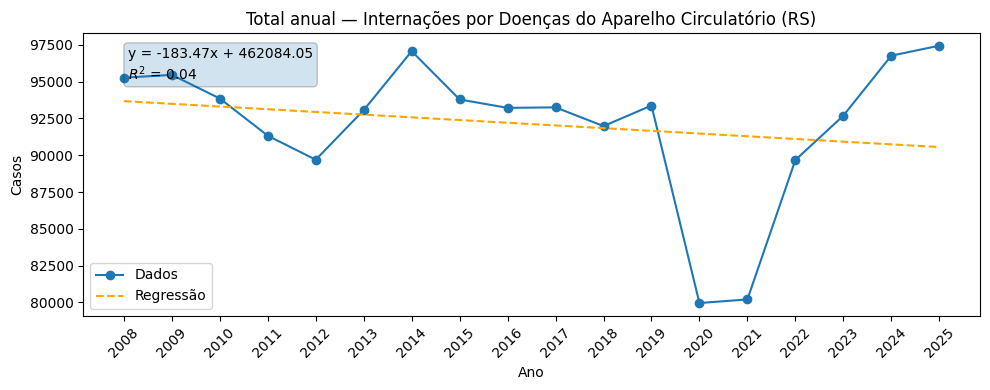

In [110]:
# --- gráfico total anual ---
y_total = df[df["Macrorregião de Saúde"] == "Total"][colunas_anos].values.flatten().astype(float)
X_total = np.array([int(a) for a in colunas_anos]).reshape(-1, 1)

model_total = LinearRegression().fit(X_total, y_total)
y_pred_total = model_total.predict(X_total)

a = model_total.coef_[0]
b = model_total.intercept_
r2 = model_total.score(X_total, y_total)

plt.figure(figsize=(10, 4))
plt.plot([int(a_) for a_ in colunas_anos], y_total, marker='o', label="Dados")
plt.plot([int(a_) for a_ in colunas_anos], y_pred_total, linestyle='--', color='orange', label="Regressão")
plt.title("Total anual — Internações por Doenças do Aparelho Circulatório (RS)")
plt.xlabel("Ano")
plt.ylabel("Casos")
plt.xticks([int(a_) for a_ in colunas_anos], rotation=45)
eq_text = f"y = {a:.2f}x + {b:.2f}\n$R^2$ = {r2:.2f}"
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.2))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- preparar dados ---
colunas_anos = [c for c in df.columns if c.isdigit()]
anos = np.array(colunas_anos, dtype=int)

# matriz de valores
Y = df[colunas_anos].astype(float).values

# matriz X com intercepto (uma vez só)
X = sm.add_constant(anos)

# --- regressão ---
slopes = []
interceptos = []
p_values = []
r2_adj = []
medias = []

for y in Y:
    model = sm.OLS(y, X).fit()

    slopes.append(model.params[1])
    interceptos.append(model.params[0])
    p_values.append(model.pvalues[1])
    r2_adj.append(model.rsquared_adj)
    medias.append(y.mean())

# converter para array
slopes = np.array(slopes)
medias = np.array(medias)

razoes = slopes / medias

# --- dataframe final ---
resultados_df = pd.DataFrame({
    "Regiao": df.iloc[:, 0],
    "Coef_Angular": slopes,
    "Intercepto": interceptos,
    "p_valor": p_values,
    "R2_ajustado": r2_adj,
    "Media": medias,
    "Razao": razoes
}).sort_values(by="Razao", ascending=False)

resultados_df.head(n=110)

,Regiao,Coef_Angular,Intercepto,p_valor,R2_ajustado,Media,Razao
5,4313 METROPOLITANA,152.116615,-265848.432061,0.095650,0.111600,40894.722222,0.003720
6,4314 CENTRO-OESTE,12.902993,-18440.162711,0.689209,-0.051598,7578.722222,0.001703
2,4310 SERRA,6.983488,-6962.703818,0.789129,-0.057611,7119.500000,0.000981
7,Total,-183.470588,462084.052288,0.426758,-0.020099,92115.611111,-0.001992
3,4311 NORTE,-38.151703,89468.630891,0.425808,-0.019928,12535.722222,-0.003043
0,4308 VALES,-69.344685,147991.057792,0.006625,0.339086,8157.500000,-0.008501
4,4312 MISSIONEIRA,-65.053664,138659.768146,0.013384,0.283548,7479.055556,-0.008698
1,4309 SUL,-182.923633,377215.894049,0.000008,0.702879,8350.388889,-0.021906


É importante analisar os coeficientes e as métricas dos modelos de regressão.
Tendo-se que a equação do modelo de regressão é $Y = ax + b$
* Coef_Angular ($a$): representa a inclinação da reta de regressão, indicando a variação média da variável dependente ($Y$) para cada unidade de aumento da variável independente ($X$). Valores positivos indicam tendência crescente, enquanto valores negativos indicam tendência decrescente.

* Intercepto ($b$): corresponde ao valor estimado de $Y$ quando $X = 0$. Ele define o ponto em que a reta intercepta o eixo $Y$ e, dependendo do contexto, pode ou não ter interpretação prática relevante.

As métricas do modelo de regressão são:
* $p-valor$: avalia a significância estatística do coeficiente estimado, testando a hipótese nula de que o coeficiente é igual a zero (ou seja, sem efeito). Valores de $p$ menores que um nível de significância (ex.: 0,05) indicam evidência de que a variável independente tem efeito estatisticamente significativo sobre $Y$.

* $R^2$-ajustado: mede a proporção da variabilidade de $Y$ explicada pelo modelo, ajustada pelo número de variáveis independentes. Diferentemente do $R^2$ simples, o $R^2$-ajustado penaliza a inclusão de variáveis desnecessárias, sendo mais apropriado para comparar modelos com diferentes números de preditores. Valores mais próximos de 1 indicam melhor ajuste do modelo aos dados.




### Mostrando o comportamento das regiões extremas: com maior crescimento e menor crescimento.

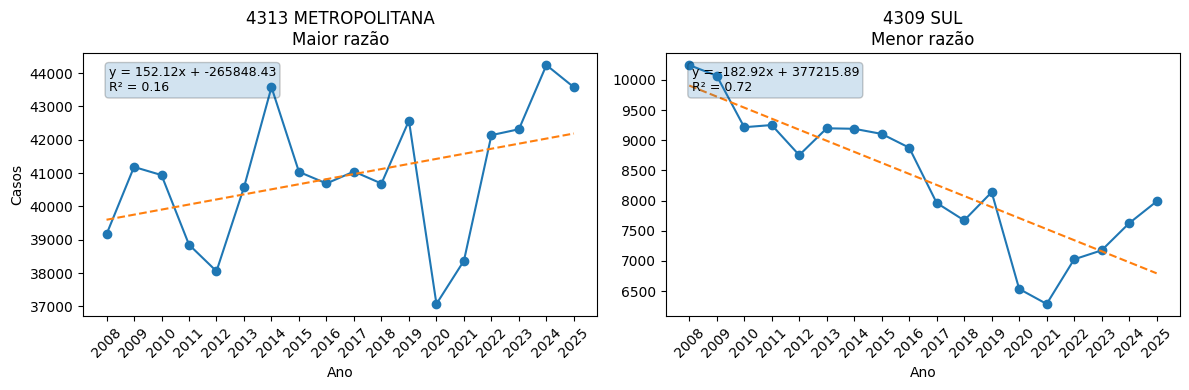

In [112]:
# --- identificar extremos ---
regiao_max = resultados_df.iloc[0]["Regiao"]
regiao_min = resultados_df.iloc[-1]["Regiao"]

# --- função para obter série ---
def get_series(regiao):
    return df.loc[df.iloc[:, 0] == regiao, colunas_anos].values.flatten()

# --- função para tendência + coeficientes ---
def trend(anos, y):
    model = LinearRegression()
    X = np.array(anos).reshape(-1, 1)
    model.fit(X, y)

    y_pred = model.predict(X)
    a = model.coef_[0]
    b = model.intercept_
    r2 = model.score(X, y)

    return y_pred, a, b, r2

# --- dados ---
y_max = get_series(regiao_max)
y_min = get_series(regiao_min)

ymax_pred, a_max, b_max, r2_max = trend(anos, y_max)
ymin_pred, a_min, b_min, r2_min = trend(anos, y_min)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_vals = anos.flatten()

# maior razão
axes[0].set_xticks([int(a) for a in anos])
axes[0].set_xticklabels([int(a) for a in anos], rotation=45)
axes[0].plot(x_vals, y_max, marker='o')
axes[0].plot(x_vals, ymax_pred, linestyle='--')
axes[0].set_title(f"{regiao_max}\nMaior razão")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Casos")

eq_max = f"y = {a_max:.2f}x + {b_max:.2f}\nR² = {r2_max:.2f}"
axes[0].text(
    0.05, 0.95, eq_max,
    transform=axes[0].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round", alpha=0.2)
)

# menor razão
axes[1].set_xticks([int(a) for a in anos])
axes[1].set_xticklabels([int(a) for a in anos], rotation=45)
axes[1].plot(x_vals, y_min, marker='o')
axes[1].plot(x_vals, ymin_pred, linestyle='--')
axes[1].set_title(f"{regiao_min}\nMenor razão")
axes[1].set_xlabel("Ano")

eq_min = f"y = {a_min:.2f}x + {b_min:.2f}\nR² = {r2_min:.2f}"
axes[1].text(
    0.05, 0.95, eq_min,
    transform=axes[1].transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.tight_layout()
plt.show()

### Mostrando o comportamento de todas as regiões.

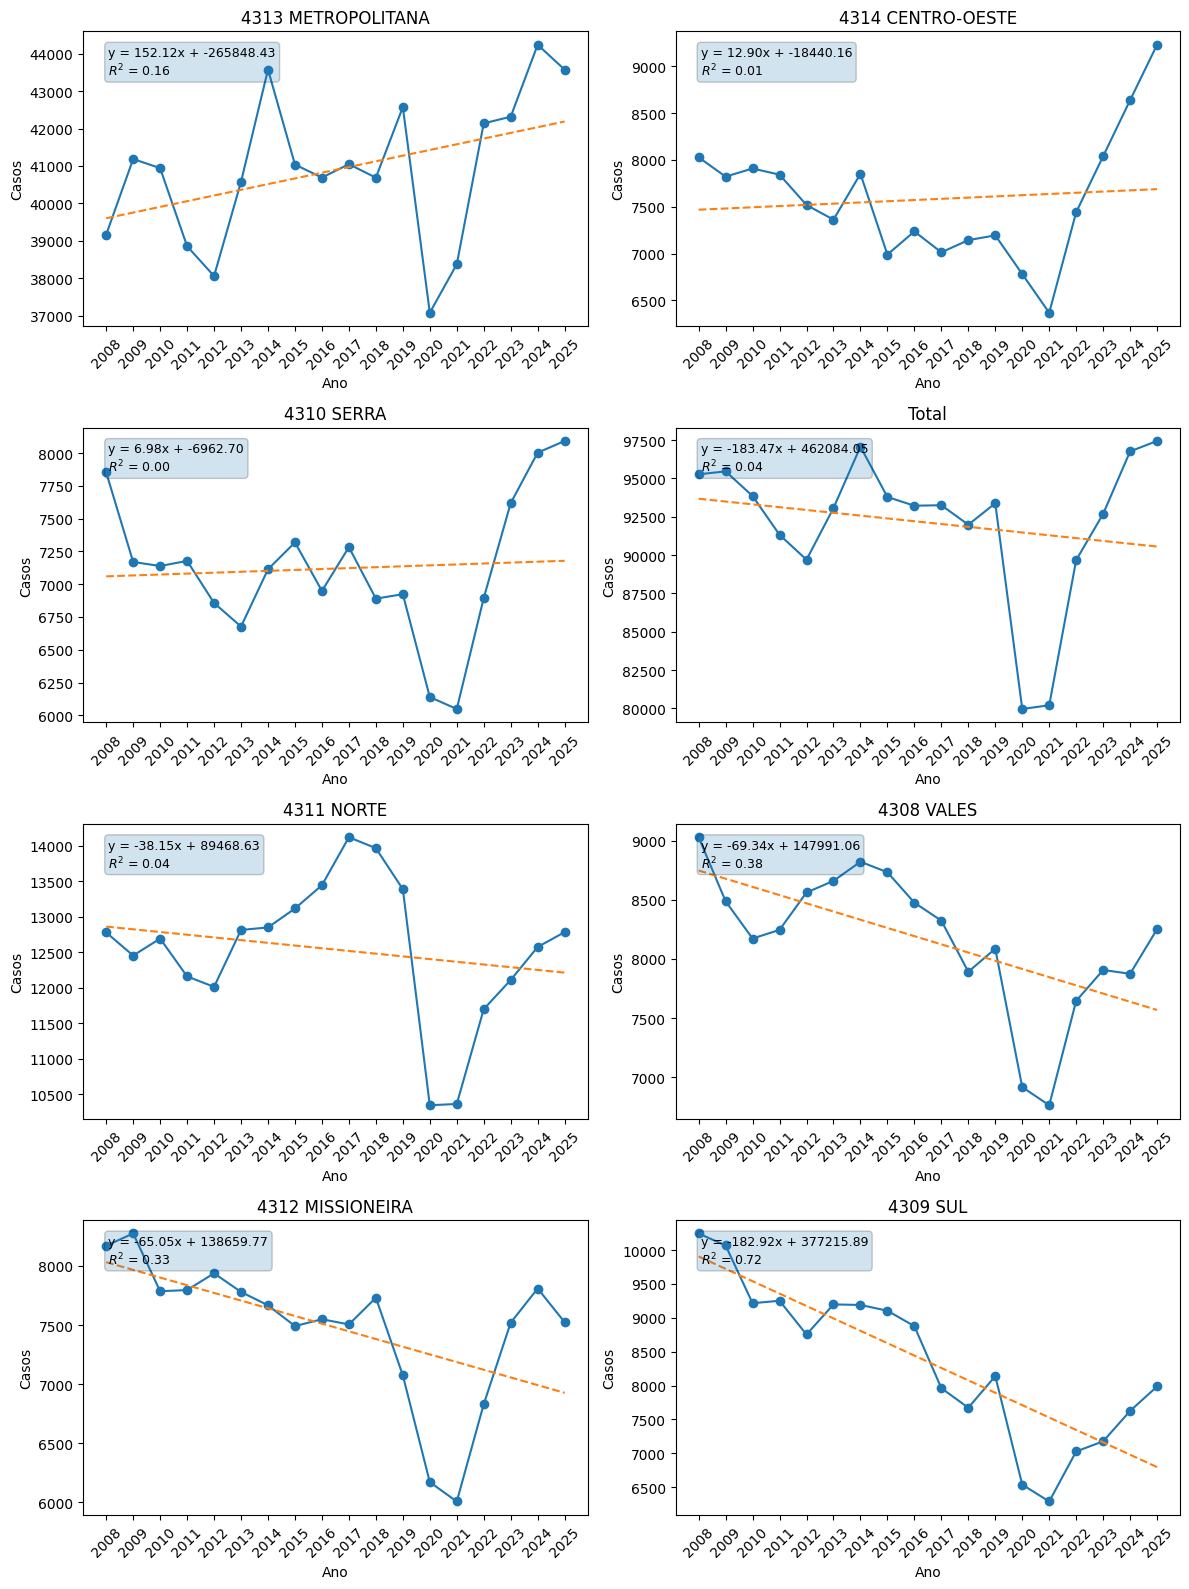

In [113]:
# --- função para obter série ---
def get_series(regiao):
    return df.loc[df.iloc[:, 0] == regiao, colunas_anos].values.flatten()

# --- função para tendência + coeficientes ---
def trend(anos, y):
    model = LinearRegression()
    X = np.array(anos).reshape(-1, 1)
    model.fit(X, y)
    y_pred = model.predict(X)

    a = model.coef_[0]
    b = model.intercept_
    r2 = model.score(X, y)  # <-- cálculo do R²

    return y_pred, a, b, r2

# --- lista de regiões ---
regioes = resultados_df["Regiao"].tolist()

# --- layout ---
n = len(regioes)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.reshape(nrows, ncols)

# --- loop ---
for i, regiao in enumerate(regioes):
    row = i // ncols
    col = i % ncols

    ax = axes[row, col]

    y = get_series(regiao)
    y_pred, a, b, r2 = trend(anos, y)

    x_vals = anos.flatten()

    ax.plot(x_vals, y, marker='o')
    ax.plot(x_vals, y_pred, linestyle='--')

    ax.set_xticks([int(a) for a in anos])
    ax.set_xticklabels([int(a) for a in anos], rotation=45)
    ax.set_title(f"{regiao}")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Casos")

    # --- equação + R² ---
    eq_text = f"y = {a:.2f}x + {b:.2f}\n$R^2$ = {r2:.2f}"

    ax.text(
        0.05, 0.95, eq_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle="round", alpha=0.2)
    )

# --- remover eixos vazios ---
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

## Análise Comparativa Normalizada

### Nota sobre os dados populacionais
Os dados populacionais são estimativas do TCU disponíveis no DATASUS, cobrindo 2008 a 2022.
Para 2023, 2024 e 2025, a população foi projetada via regressão linear com base na série histórica.

Fonte: DATASUS — Estimativas de população residente utilizadas pelo TCU para determinação das cotas do FPM.


##Carregando os dados de população (2008-2022) e projetando os dados de 2023, 2024 e 2025 via regressão linear

In [ ]:
# --- carga da população ---
pop_df = pd.read_csv("https://raw.githubusercontent.com/ThalesKun/data-science/refs/heads/main/pop.txt", sep=";")
pop_df = pop_df[pop_df["Macrorregião de Saúde"] != "Total"]
pop_df = pop_df.set_index("Macrorregião de Saúde")

# --- projeção 2023, 2024 e 2025 por regressão linear ---
anos_pop_treino = np.array(range(2008, 2023)).reshape(-1, 1)
projecoes = {str(ano): [] for ano in [2023, 2024, 2025]}

for regiao in pop_df.index:
    y_pop = pop_df.loc[regiao].values.astype(float)
    model_pop = LinearRegression().fit(anos_pop_treino, y_pop)
    for ano in [2023, 2024, 2025]:
        projecoes[str(ano)].append(int(model_pop.predict([[ano]])[0]))

for ano in [2023, 2024, 2025]:
    pop_df[str(ano)] = projecoes[str(ano)]

print("População projetada para 2023-2025:")
print(pop_df[["2023", "2024", "2025"]])

População projetada para 2023-2025:
                          2023     2024     2025
Macrorregião de Saúde                           
4308 VALES              921122   925155   929188
4309 SUL               1055667  1056676  1057685
4310 SERRA             1262694  1276334  1289973
4311 NORTE             1257830  1260089  1262347
4312 MISSIONEIRA        863730   862496   861262
4313 METROPOLITANA     5049994  5073252  5096509
4314 CENTRO-OESTE      1037796  1036966  1036135


In [111]:
pop_df.head(n=10)

,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Macrorregião de Saúde,,,,,,,,,,,,,,,,,,
4308 VALES,866100,871237,852902,856214,859498,891032,894705,898160,901434,904525,906510,910656,914636,918437,886802,921122,925155,929188
4309 SUL,1042710,1045925,1020053,1021833,1023176,1059422,1061796,1064030,1066148,1068146,1057454,1059287,1061047,1062724,1000182,1055667,1056676,1057685
4310 SERRA,1054147,1065782,1076881,1087962,1098727,1142413,1152210,1161443,1170170,1178425,1214330,1227667,1240319,1252455,1180749,1262694,1276334,1289973
4311 NORTE,1233988,1237380,1205671,1206777,1207884,1250377,1252803,1255091,1257262,1259313,1244308,1245819,1247349,1248799,1243651,1257830,1260089,1262347
4312 MISSIONEIRA,883418,881517,865836,863612,861518,890353,889845,889367,888915,888485,863103,860740,858481,856324,862533,863730,862496,861262
4313 METROPOLITANA,4724943,4762307,4645284,4668926,4692949,4868356,4893151,4916484,4938572,4959437,5001217,5031210,5060068,5087564,4708536,5049994,5073252,5096509
4314 CENTRO-OESTE,1049908,1049980,1028905,1027706,1026851,1062090,1062764,1063397,1063999,1064564,1042683,1041860,1041073,1040327,1000512,1037796,1036966,1036135


##Gráfico da população por macrorregião

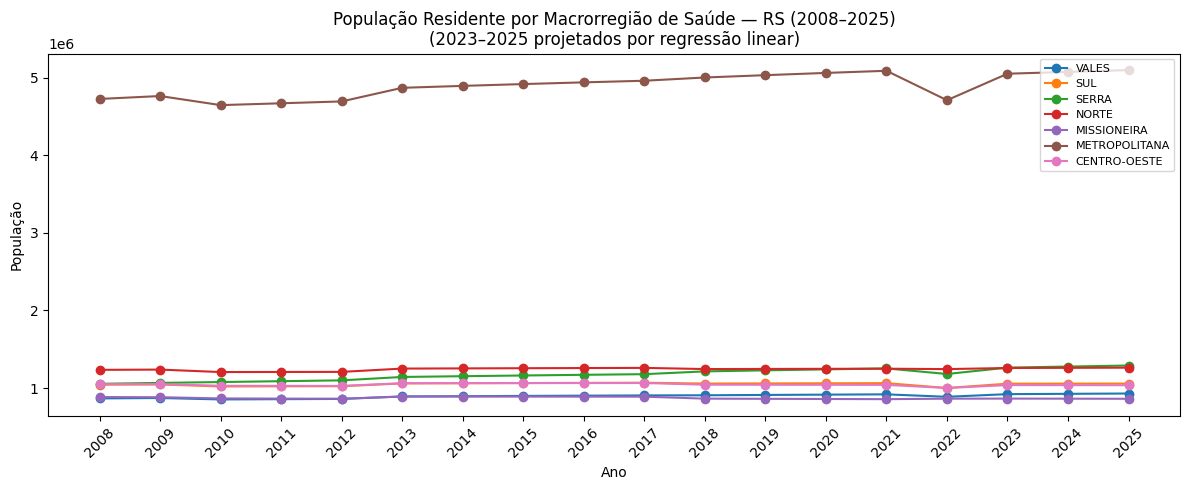

In [ ]:
# --- gráfico da população por macrorregião ---
fig, ax = plt.subplots(figsize=(12, 5))

colunas_pop = [str(a) for a in range(2008, 2026)]

for regiao in pop_df.index:
    ax.plot(
        range(2008, 2026),
        pop_df.loc[regiao, colunas_pop].astype(float),
        marker='o',
        label=regiao.split(" ", 1)[1]
    )

ax.set_title("População Residente por Macrorregião de Saúde — RS (2008–2025)\n(2023–2025 projetados por regressão linear)")
ax.set_xlabel("Ano")
ax.set_ylabel("População")
ax.set_xticks(range(2008, 2026))
ax.set_xticklabels(range(2008, 2026), rotation=45)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

##Normalização por 100 mil habitantes e mostrando as médias por macrorregião

In [ ]:
# --- normalização: internações por 100 mil habitantes ---
intern_df = df[df["Macrorregião de Saúde"] != "Total"].copy()
intern_df = intern_df.set_index("Macrorregião de Saúde")[colunas_anos]

taxa_df = pd.DataFrame(index=pop_df.index, columns=colunas_anos, dtype=float)

for regiao in pop_df.index:
    for ano in colunas_anos:
        internacoes = intern_df.loc[regiao, ano]
        populacao = pop_df.loc[regiao, str(ano)]
        taxa_df.loc[regiao, ano] = round((internacoes / populacao) * 100_000, 1)

# --- ranking por taxa média ---
taxa_df["Media"] = taxa_df.mean(axis=1)
print(taxa_df[["Media"]].sort_values("Media", ascending=False))

                             Media
Macrorregião de Saúde             
4311 NORTE             1008.388889
4308 VALES              913.016667
4312 MISSIONEIRA        857.655556
4313 METROPOLITANA      835.266667
4309 SUL                796.477778
4314 CENTRO-OESTE       726.883333
4310 SERRA              608.866667


##Gráfico comparativo da normalização por 100 mil habitantes e macrorregiões do RS

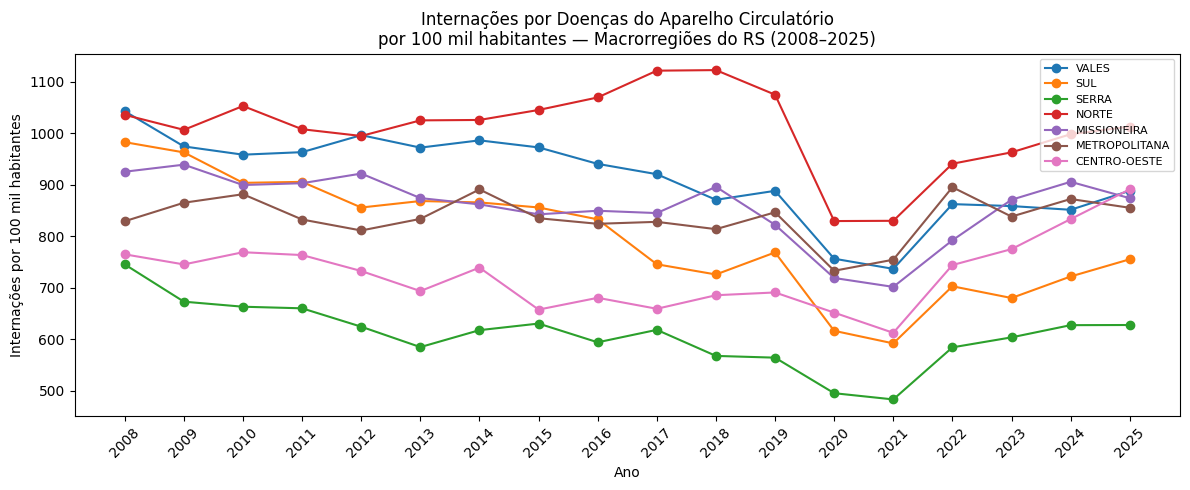

In [ ]:
# --- gráfico comparativo normalizado ---
fig, ax = plt.subplots(figsize=(12, 5))

for regiao in taxa_df.index:
    ax.plot(
        [int(a) for a in colunas_anos],
        taxa_df.loc[regiao, colunas_anos].astype(float),
        marker='o',
        label=regiao.split(" ", 1)[1]
    )

ax.set_title("Internações por Doenças do Aparelho Circulatório\npor 100 mil habitantes — Macrorregiões do RS (2008–2025)")
ax.set_xlabel("Ano")
ax.set_ylabel("Internações por 100 mil habitantes")
ax.legend(loc="upper right", fontsize=8)
ax.set_xticks([int(a) for a in colunas_anos])
ax.set_xticklabels([int(a) for a in colunas_anos], rotation=45)
plt.tight_layout()
plt.show()

## Resultados e Conclusão

### Análise de Tendência Temporal

Ao aplicar a regressão linear nas internações por doenças do aparelho circulatório
(CID-10, Capítulo IX) nas macrorregiões do Rio Grande do Sul entre 2008 e 2025,
observamos que **nenhuma macrorregião apresentou crescimento estatisticamente significativo**
no período analisado (p > 0,05). Pelo contrário, identificamos três regiões com tendência
de **queda significativa**:

- **SUL**: queda de ~183 internações/ano (p < 0,001, R² = 0,70) — a tendência mais
forte e confiável do estudo, com 70% da variação explicada pelo tempo
- **VALES**: queda de ~69 internações/ano (p = 0,007, R² = 0,34)
- **MISSIONEIRA**: queda de ~65 internações/ano (p = 0,013, R² = 0,28)

A macrorregião METROPOLITANA apresentou a maior razão positiva (0,0037), sugerindo
leve tendência de crescimento, porém sem significância estatística (p = 0,096).

Em todas as regiões, observamos uma queda acentuada em **2020 e 2021**, reflexo
da pandemia de COVID-19, com retomada gradual a partir de **2022**.

### Análise Comparativa Normalizada

Analisando os dados brutos, verificamos que a macrorregião **METROPOLITANA** domina
em volume absoluto (~40.894 internações/ano em média), o que é esperado dado que
concentra aproximadamente **4,7 milhões de habitantes**.

Após normalizarmos os dados por **100 mil habitantes**, constatamos que a macrorregião
**NORTE** assume a maior taxa ao longo de praticamente todo o período, atingindo picos
superiores a **1.100 internações por 100 mil habitantes** em 2017 e 2018. Já a
macrorregião **SERRA** apresentou consistentemente as menores taxas, ficando abaixo
de **700 por 100 mil habitantes** em vários anos.

Essa inversão evidencia a importância da normalização: ao analisarmos os dados
proporcionalmente, percebemos que a NORTE apresenta maior vulnerabilidade às doenças
circulatórias do que os números absolutos sugerem, o que pode estar associado a
perfil demográfico mais envelhecido, menor acesso a serviços preventivos e
condições socioeconômicas da região.

Vale destacar que, para os anos de 2023 a 2025, utilizamos projeções populacionais
obtidas por regressão linear, dado que os dados oficiais do DATASUS/TCU disponíveis
cobrem apenas até 2022. Essa limitação deve ser considerada na interpretação dos
resultados mais recentes.

### Conclusão

As doenças do aparelho circulatório representam uma carga expressiva para o sistema
de saúde gaúcho. A partir dos dados analisados, concluímos que a tendência geral
de queda nas internações em várias macrorregiões pode indicar avanços na atenção
primária e prevenção, embora o impacto da pandemia de COVID-19 também contribua
para essa redução.

A macrorregião **SUL** apresentou a queda mais expressiva e estatisticamente
robusta. Já a macrorregião **NORTE**, embora não apresente crescimento
significativo, mantém as maiores taxas proporcionais de internação ao longo
de todo o período analisado, o que indica necessidade de maior atenção às
políticas de saúde cardiovascular na região.